In [299]:
import pandas as pd
import numpy as np

In [300]:
df=pd.read_csv('train-test.csv')

In [301]:
df.head()

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


In [302]:
# Target is posted_rate 
target = df['posted_rate']

In [303]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   load_id       48000 non-null  object 
 1   pickup        48000 non-null  object 
 2   delivery      48000 non-null  object 
 3   pickup_lat    48000 non-null  float64
 4   pickup_lon    48000 non-null  float64
 5   delivery_lat  48000 non-null  float64
 6   delivery_lon  48000 non-null  float64
 7   distance      48000 non-null  float64
 8   equipment     48000 non-null  object 
 9   weight        47700 non-null  float64
 10  date          48000 non-null  object 
 11  market_index  47626 non-null  float64
 12  quote_signal  48000 non-null  float64
 13  posted_rate   48000 non-null  float64
dtypes: float64(9), object(5)
memory usage: 5.1+ MB


In [304]:
max(df['market_index'].unique())

np.float64(1.46778)

In [305]:
df.loc[df['weight'] < 0, 'weight'] = np.nan

In [306]:
wt_missing=df.groupby('equipment', as_index=False)['weight'].mean()
df['weight'] = df['weight'].fillna(df['equipment'].map(wt_missing.set_index('equipment')['weight']))

In [307]:
##  market_index means what is the type of market, 
# A higher market_index generally means capacity is tighter / demand is stronger / market rates are higher,

## A quote_signal generally represents some signal related to the expected/quoted price for a particular load.


In [308]:
from matplotlib import pyplot as plt


<Axes: xlabel='equipment'>

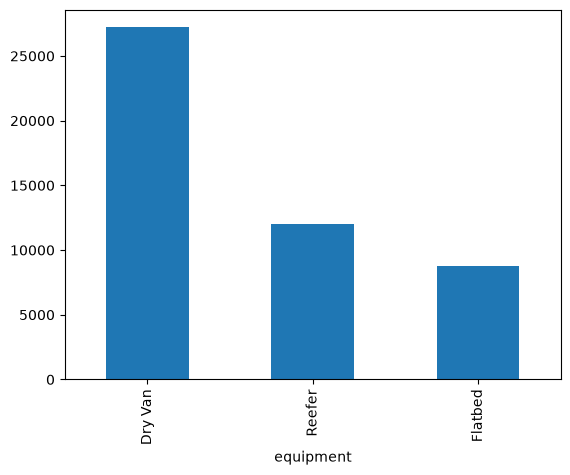

In [309]:
df['equipment'].value_counts().plot(kind='bar')

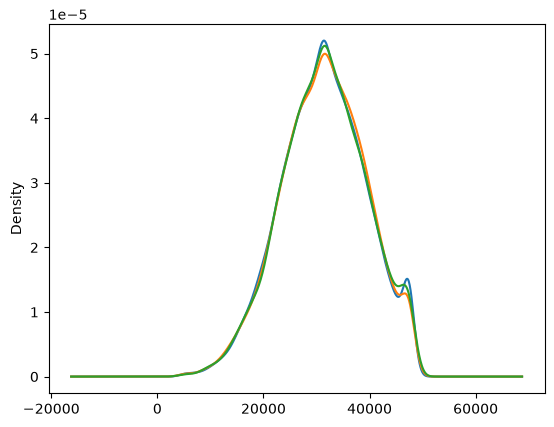

In [310]:
total_equipment = df['equipment'].value_counts().index
for equipment in total_equipment:
    df[df['equipment']==equipment]['weight'].plot(kind='kde', label=equipment)



In [311]:
(df['weight'] < 0).sum()
(df['weight'] < 0).mean() * 100

np.float64(0.0)

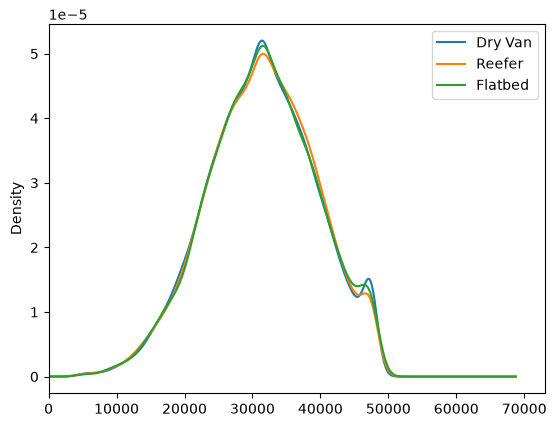

In [312]:
total_equipment = df['equipment'].value_counts().index
for equipment in total_equipment:
    df[df['equipment']==equipment]['weight'].plot(kind='kde', label=equipment)
plt.xlim(left=0)

plt.legend()
plt.show()

In [313]:
df.groupby('equipment')['weight'].agg(['count', 'mean', 'median', 'std'])

,count,mean,median,std
equipment,,,,
Dry Van,27202,31388.566798,31388.566798,7957.696272
Flatbed,8753,31475.339128,31475.339128,7939.630658
Reefer,12045,31432.359002,31467.000000,7922.331549


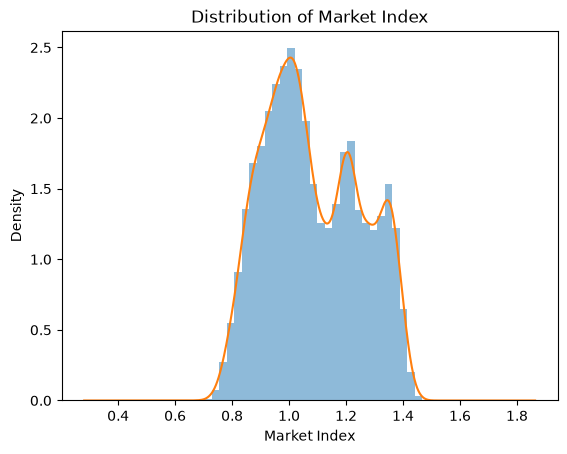

In [314]:
import matplotlib.pyplot as plt

df['market_index'].plot(
    kind='hist',
    bins=30,
    density=True,
    alpha=0.5
)

df['market_index'].plot(
    kind='kde'
)

plt.xlabel('Market Index')
plt.ylabel('Density')
plt.title('Distribution of Market Index')
plt.show()

In [315]:
print(df['market_index'].skew())

0.21426317657348978


In [316]:
df['market_index'].agg(['mean', 'median', 'std', 'min', 'max'])

mean      1.083387
median    1.055800
std       0.168091
min       0.676390
max       1.467780
Name: market_index, dtype: float64

In [317]:
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')

<Axes: xlabel='date'>

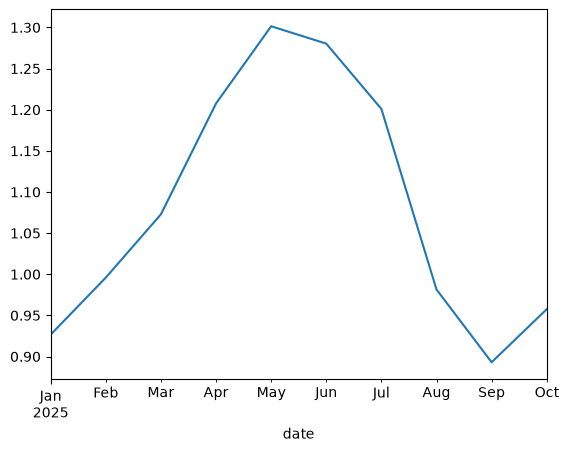

In [318]:
df.groupby(df['date'].dt.to_period('M'))['market_index'].mean().plot()

In [319]:
df.groupby(df['date'].dt.month)['market_index'].mean()

date
1     0.926696
2     0.995997
3     1.072880
4     1.207649
5     1.301452
6     1.280316
7     1.200893
8     0.981480
9     0.893039
10    0.957502
Name: market_index, dtype: float64

In [320]:
month_mean = df.groupby(df['date'].dt.month)['market_index'].transform('mean')

df['market_index'] = df['market_index'].fillna(month_mean)

In [321]:
df['month'] = df['date'].dt.month
df['day_of_week'] = df['date'].dt.dayofweek
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

In [322]:
df.describe()

,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,weight,date,market_index,quote_signal,posted_rate,month,day_of_week,is_weekend
count,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,48000,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000
mean,35.647545,-90.928964,35.641175,-90.857310,1135.856654,31415.379200,2025-05-31 19:53:29.400000,1.083427,2.062468,2373.980682,5.505312,3.003146,0.282875
min,28.357650,-121.698490,28.357650,-121.698490,70.000000,5000.000000,2025-01-01 00:00:00,0.676390,0.692280,57.220000,1.000000,0.000000,0.000000
25%,31.986910,-98.400590,31.986910,-98.400590,550.400000,26007.750000,2025-03-18 00:00:00,0.949897,1.891030,1251.555000,3.000000,1.000000,0.000000
50%,35.294790,-88.089150,35.294790,-87.528710,953.300000,31432.359002,2025-05-31 00:00:00,1.055865,2.055750,2030.760000,5.000000,3.000000,0.000000
75%,39.411040,-83.285060,39.411040,-83.285060,1645.525000,36985.000000,2025-08-15 00:00:00,1.219510,2.221685,3330.750000,8.000000,5.000000,1.000000
max,44.302960,-69.500000,44.302960,-69.500000,3439.800000,47500.000000,2025-10-31 00:00:00,1.467780,3.610350,25533.000000,10.000000,6.000000,1.000000
std,4.315285,13.482431,4.317199,13.476589,728.564416,7945.448037,NaN,0.167928,0.291391,1486.493245,2.864084,1.990637,0.450401


In [323]:
final_df = df.drop(columns=['date', 'day_of_week'])

In [324]:
final_df=df.drop(['date','load_id'], axis=1)

In [325]:
final_df.head()

,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,market_index,quote_signal,posted_rate,month,day_of_week,is_weekend
0,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,0.95684,2.39595,645.41,1,2,0
1,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,0.97623,2.43355,679.97,1,2,0
2,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,1.00971,1.84491,1802.54,1,2,0
3,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,0.94518,1.87712,1827.28,1,2,0
4,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,0.98480,2.56300,1380.28,1,2,0


In [326]:
from sklearn.model_selection import train_test_split
X = final_df.drop(columns=['posted_rate'])
y = final_df['posted_rate']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
categorical_cols = ['equipment', 'pickup', 'delivery', 'is_weekend','month']

from catboost import CatBoostRegressor
model = CatBoostRegressor(
    iterations=500,
    depth=7,
    learning_rate=0.05,
    verbose=False
)

model.fit(
    X_train,
    y_train,
    cat_features=categorical_cols
)

CatBoostRegressor(depth=7, iterations=500, learning_rate=0.05, loss_function='RMSE', verbose=False)

In [328]:
model.score(X_test, y_test)

np.float64(0.8622347718825678)

In [329]:
from sklearn.metrics import r2_score
y_pred=model.predict(X_test)
score=r2_score(y_test, y_pred)
print(f"end=to-end R2 score: {score:.4f}")

end=to-end R2 score: 0.8622


In [330]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

print("Train R2:", r2_score(y_train, train_pred))
print("Test R2:", r2_score(y_test, test_pred))

print("Train MAE:", mean_absolute_error(y_train, train_pred))
print("Test MAE:", mean_absolute_error(y_test, test_pred))

print("Train RMSE:", mean_squared_error(y_train, train_pred) ** 0.5)
print("Test RMSE:", mean_squared_error(y_test, test_pred) ** 0.5)

Train R2: 0.8485348253121516
Test R2: 0.8622347718825678
Train MAE: 107.10941947064376
Test MAE: 105.00056232575194
Train RMSE: 582.3612078913479
Test RMSE: 543.07724009734


In [331]:
print(y.sort_values(ascending=False).head(20))

12184    25533.00
37764    24294.98
1466     24140.21
17371    23662.71
26235    23580.42
28219    22755.66
3353     22534.65
40171    20361.89
40096    20132.37
47298    19110.30
31259    19042.39
34583    18972.15
46213    17893.17
20245    17772.53
35468    17742.34
4657     17688.63
43539    17514.11
33074    17333.65
32352    16951.43
17763    16841.60
Name: posted_rate, dtype: float64


(array([3.0664e+04, 1.5482e+04, 1.7060e+03, 5.1000e+01, 4.7000e+01,
        2.8000e+01, 9.0000e+00, 6.0000e+00, 2.0000e+00, 5.0000e+00]),
 array([   57.22 ,  2604.798,  5152.376,  7699.954, 10247.532, 12795.11 ,
        15342.688, 17890.266, 20437.844, 22985.422, 25533.   ]),
 <BarContainer object of 10 artists>)

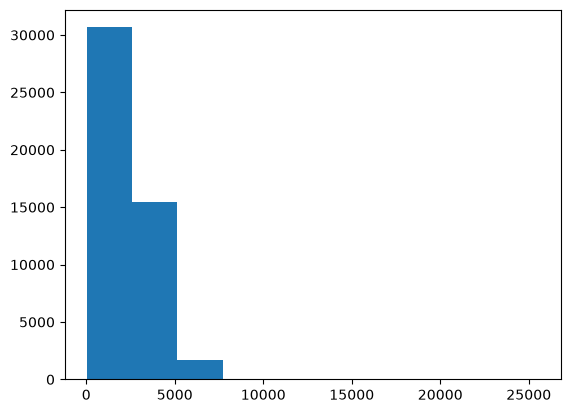

In [332]:
plt.hist(y)

In [333]:
import numpy as np

y_train_log = np.log1p(y_train)

In [334]:
model.fit(
    X_train,
    y_train_log,
    cat_features=categorical_cols
)

CatBoostRegressor(depth=7, iterations=500, learning_rate=0.05, loss_function='RMSE', verbose=False)

In [335]:
pred_log = model.predict(X_test)
pred = np.expm1(pred_log)

In [336]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print("R2:", r2_score(y_test, pred))
print("MAE:", mean_absolute_error(y_test, pred))
print("RMSE:", mean_squared_error(y_test, pred) ** 0.5)

R2: 0.8636741730841153
MAE: 93.06773147115274
RMSE: 540.2326956554883


In [337]:
final_df.head()

,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,market_index,quote_signal,posted_rate,month,day_of_week,is_weekend
0,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,0.95684,2.39595,645.41,1,2,0
1,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,0.97623,2.43355,679.97,1,2,0
2,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,1.00971,1.84491,1802.54,1,2,0
3,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,0.94518,1.87712,1827.28,1,2,0
4,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,0.98480,2.56300,1380.28,1,2,0


In [338]:
## dropping ciites

dc=df.drop(['pickup','delivery'], axis=1)

In [339]:
X_train, X_test, y_train, y_test = train_test_split(dc.drop(columns=['posted_rate','load_id','date']), dc['posted_rate'], test_size=0.3, random_state=42)

In [340]:
y_train_log = np.log1p(y_train)
categorical_cols = ['equipment', 'is_weekend','month']


model.fit(
    X_train,
    y_train_log,
    cat_features=categorical_cols 
)

CatBoostRegressor(depth=7, iterations=500, learning_rate=0.05, loss_function='RMSE', verbose=False)

## Training with LightGBM

In [341]:
X_train, X_test, y_train, y_test = train_test_split(dc.drop(columns=['posted_rate','load_id','date']), dc['posted_rate'], test_size=0.3, random_state=42)

In [342]:
y_train_log = np.log1p(y_train)


In [343]:
from lightgbm import LGBMRegressor
categorical_cols = ['equipment', 'is_weekend','month']
X_train_lgb = X_train.copy()
X_test_lgb = X_test.copy()

for col in categorical_cols:
    X_train_lgb[col] = X_train_lgb[col].astype('category')
    X_test_lgb[col] = X_test_lgb[col].astype('category')


lgb_model = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    random_state=42
)

lgb_model.fit(
    X_train_lgb,
    y_train_log,
    categorical_feature=categorical_cols
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003587 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1303
[LightGBM] [Info] Number of data points in the train set: 33600, number of used features: 12
[LightGBM] [Info] Start training from score 7.572863


,learning_rate,0.05
,n_estimators,1000
,random_state,42
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001


In [344]:
# LightGBM predictions
lgb_train_log = lgb_model.predict(X_train_lgb)
lgb_test_log = lgb_model.predict(X_test_lgb)

lgb_train_pred = np.expm1(lgb_train_log)
lgb_test_pred = np.expm1(lgb_test_log)

print("===== LightGBM =====")
print("Train R2:", r2_score(y_train, lgb_train_pred))
print("Test R2:", r2_score(y_test, lgb_test_pred))

print("Train MAE:", mean_absolute_error(y_train, lgb_train_pred))
print("Test MAE:", mean_absolute_error(y_test, lgb_test_pred))

print("Train RMSE:", mean_squared_error(y_train, lgb_train_pred) ** 0.5)
print("Test RMSE:", mean_squared_error(y_test, lgb_test_pred) ** 0.5)

===== LightGBM =====
Train R2: 0.8771605311788263
Test R2: 0.8596783818016398
Train MAE: 96.39941422265754
Test MAE: 115.0294212079136
Train RMSE: 524.4511088949554
Test RMSE: 548.0927868684718


In [345]:
dc = df.drop(['pickup', 'delivery'], axis=1)

dc["distance_bin"] = pd.cut(
    dc["distance"],
    bins=[0, 500, 1000, 1500, 2000, 3000, np.inf],
    labels=[
        "0-500",
        "500-1000",
        "1000-1500",
        "1500-2000",
        "2000-3000",
        "3000+"
    ]
)

dc["distance_equipment"] = (
    dc["distance_bin"].astype(str) + "_" +
    dc["equipment"].astype(str)
)

# We only need the interaction, so remove the intermediate column
dc = dc.drop(columns=["distance_bin"])

categorical_cols = [
    'equipment',
    'is_weekend',
    'month',
    'distance_equipment'
]
X = dc.drop(columns=["posted_rate", "load_id", "date"])
y = dc["posted_rate"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

y_train_log = np.log1p(y_train)

model.fit(
    X_train,
    y_train_log,
    cat_features=categorical_cols
)

cb_train_log = model.predict(X_train)
cb_test_log = model.predict(X_test)

cb_train_pred = np.expm1(cb_train_log)
cb_test_pred = np.expm1(cb_test_log)

print("===== CatBoost =====")
print("Train R2:", r2_score(y_train, cb_train_pred))
print("Test R2:", r2_score(y_test, cb_test_pred))

print("Train MAE:", mean_absolute_error(y_train, cb_train_pred))
print("Test MAE:", mean_absolute_error(y_test, cb_test_pred))

print("Train RMSE:", mean_squared_error(y_train, cb_train_pred) ** 0.5)
print("Test RMSE:", mean_squared_error(y_test, cb_test_pred) ** 0.5)

===== CatBoost =====
Train R2: 0.838560521967374
Test R2: 0.8633820335534655
Train MAE: 95.3403926157451
Test MAE: 94.2733970265225
Train RMSE: 601.2303775506748
Test RMSE: 540.8112319031313


### clearly CatBoost is performing better 

In [ ]:
importance = model.get_feature_importance()

feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importance
}).sort_values('importance', ascending=False)

print(feature_importance)

               feature  importance
4             distance   91.904297
5            equipment    2.539390
6               weight    1.035399
7         market_index    0.744773
8         quote_signal    0.633789
1           pickup_lon    0.588659
9                month    0.571916
3         delivery_lon    0.544946
0           pickup_lat    0.524730
2         delivery_lat    0.426546
12  distance_equipment    0.333896
10         day_of_week    0.117609
11          is_weekend    0.034049


In [442]:
import numpy as np
import pandas as pd

def engineer_features(df_input: pd.DataFrame) -> pd.DataFrame:
    dc = df_input.copy()

    # 2. Physics & Logistics Work Interactions
    dc['ton_miles'] = dc['distance'] * (dc['weight'] / 2000.0)
    # dc['weight_per_mile'] = dc['weight'] / (dc['distance'] + 1.0)
    dc['log_distance'] = np.log1p(dc['distance'])
    # dc['sqrt_distance'] = np.sqrt(dc['distance'])

    # 3. Market Signals Interactions (if present)
    if 'quote_signal' in dc.columns and 'market_index' in dc.columns:
        dc['distance_x_quote'] = dc['distance'] * dc['quote_signal']
        dc['distance_x_market'] = dc['distance'] * dc['market_index']
        # dc['market_x_quote'] = dc['market_index'] * dc['quote_signal']
        # dc['quote_per_ton'] = dc['quote_signal'] / (dc['weight'] / 2000.0 + 1.0)
        # dc['market_tightness']     = dc['market_index'] * dc['quote_signal']
        # dc['quote_market_ratio']   = dc['quote_signal'] / (dc['market_index'] + 1e-5)
        # dc['log_quote_market_ratio'] = np.log1p(dc['quote_market_ratio'])

    # 4. Geospatial / Lane Interactions (if coordinates present)
    dc['pickup_zone']   = dc['pickup_lat'].round(1).astype(str) + "_" + dc['pickup_lon'].round(1).astype(str)
    dc['delivery_zone'] = dc['delivery_lat'].round(1).astype(str) + "_" + dc['delivery_lon'].round(1).astype(str)
    dc['lane'] = dc['pickup_zone'] + "_to_" + dc['delivery_zone']
    dc['market_tightness']       = dc['market_index'] * dc['quote_signal']
    dc['quote_market_ratio']     = dc['quote_signal'] / (dc['market_index'] + 1e-5)
    dc['log_quote_market_ratio'] = np.log1p(dc['quote_market_ratio'])

    return dc

In [443]:
df.columns

Index(['load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon',
       'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight',
       'date', 'market_index', 'quote_signal', 'posted_rate', 'month',
       'day_of_week', 'is_weekend'],
      dtype='object')

In [462]:
dc = df.copy()
X_train, X_test, y_train, y_test = train_test_split(dc.drop(columns=['posted_rate', 'load_id', 'date']), dc['posted_rate'], test_size=0.3, random_state=42)


In [463]:
dc.columns

Index(['load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon',
       'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight',
       'date', 'market_index', 'quote_signal', 'posted_rate', 'month',
       'day_of_week', 'is_weekend'],
      dtype='object')

In [464]:
X_train=engineer_features(X_train)
X_test=engineer_features(X_test)



In [ ]:
categorical_cols = [
    'equipment',
    'is_weekend',
    'month',
    'day_of_week',
    'pickup_zone',
    'delivery_zone',
    'lane',
    'pickup',
    'delivery'
]

cap = y.quantile(0.99)
print(f"Capping at: {cap}")  # likely around 7000-8000
# Cap training target
y_train_capped = y_train.clip(upper=cap)
y_train_log    = np.log1p(y_train_capped)

# y_train_log = np.log1p(y_train)


from catboost import CatBoostRegressor
from lightgbm import L
model = CatBoostRegressor(
    iterations=2000,
    depth=8,
    learning_rate=0.03,
    loss_function='RMSE',
    eval_metric='RMSE',
    verbose=100,
    random_seed=42
)





model.fit(
    X_train.drop(['distance'],axis=1),
    y_train_log,
    cat_features=categorical_cols
)
cb_train_log = model.predict(X_train.drop(['distance'],axis=1))
cb_test_log = model.predict(X_test.drop(['distance'],axis=1 ))

cb_train_pred = np.expm1(cb_train_log)
cb_test_pred = np.expm1(cb_test_log)

print("===== CatBoost =====")
print("Train R2:", r2_score(y_train, cb_train_pred))
print("Test R2:", r2_score(y_test, cb_test_pred))

print("Train MAE:", mean_absolute_error(y_train, cb_train_pred))
print("Test MAE:", mean_absolute_error(y_test, cb_test_pred))

print("Train RMSE:", mean_squared_error(y_train, cb_train_pred) ** 0.5)
print("Test RMSE:", mean_squared_error(y_test, cb_test_pred) ** 0.5)

Capping at: 5972.834000000003
0:	learn: 0.6434571	total: 135ms	remaining: 4m 30s
100:	learn: 0.1488741	total: 9.39s	remaining: 2m 56s
200:	learn: 0.1397046	total: 18.7s	remaining: 2m 47s
300:	learn: 0.1379943	total: 28.2s	remaining: 2m 39s
400:	learn: 0.1367859	total: 37.6s	remaining: 2m 29s
500:	learn: 0.1357924	total: 46.9s	remaining: 2m 20s
600:	learn: 0.1347847	total: 56.2s	remaining: 2m 10s
700:	learn: 0.1338524	total: 1m 5s	remaining: 2m 2s
800:	learn: 0.1330098	total: 1m 15s	remaining: 1m 53s
900:	learn: 0.1320093	total: 1m 25s	remaining: 1m 44s
1000:	learn: 0.1312547	total: 1m 35s	remaining: 1m 35s
1100:	learn: 0.1303516	total: 1m 49s	remaining: 1m 29s
1200:	learn: 0.1294266	total: 2m 3s	remaining: 1m 21s
1300:	learn: 0.1285161	total: 2m 14s	remaining: 1m 12s
1400:	learn: 0.1276548	total: 2m 24s	remaining: 1m 1s
1500:	learn: 0.1269715	total: 2m 34s	remaining: 51.4s
1600:	learn: 0.1262256	total: 2m 45s	remaining: 41.1s
1700:	learn: 0.1255304	total: 2m 55s	remaining: 30.8s
1800:	

In [489]:
parameter={"Best params": {'iterations': 876, 'depth': 7, 'learning_rate': 0.07053148199951062, 'l2_leaf_reg': 4.914125067552417, 'min_data_in_leaf': 10}}
from catboost import CatBoostRegressor
m = CatBoostRegressor(**parameter["Best params"])
test_df=pd.read_csv('validation.csv')
m.fit(
    X_train.drop(['distance'],axis=1),
    y_train_log,
    cat_features=categorical_cols
)



0:	learn: 0.6206462	total: 200ms	remaining: 2m 55s
1:	learn: 0.5819375	total: 330ms	remaining: 2m 24s
2:	learn: 0.5465025	total: 489ms	remaining: 2m 22s
3:	learn: 0.5134399	total: 611ms	remaining: 2m 13s
4:	learn: 0.4830304	total: 727ms	remaining: 2m 6s
5:	learn: 0.4543643	total: 864ms	remaining: 2m 5s
6:	learn: 0.4278809	total: 1.04s	remaining: 2m 9s
7:	learn: 0.4033971	total: 1.27s	remaining: 2m 18s
8:	learn: 0.3810225	total: 1.36s	remaining: 2m 11s
9:	learn: 0.3612043	total: 1.46s	remaining: 2m 6s
10:	learn: 0.3421738	total: 1.59s	remaining: 2m 4s
11:	learn: 0.3244631	total: 1.71s	remaining: 2m 3s
12:	learn: 0.3078435	total: 1.83s	remaining: 2m 1s
13:	learn: 0.2927863	total: 2.02s	remaining: 2m 4s
14:	learn: 0.2788826	total: 2.2s	remaining: 2m 6s
15:	learn: 0.2661594	total: 2.35s	remaining: 2m 6s
16:	learn: 0.2542651	total: 2.47s	remaining: 2m 4s
17:	learn: 0.2435929	total: 2.59s	remaining: 2m 3s
18:	learn: 0.2336877	total: 2.7s	remaining: 2m 1s
19:	learn: 0.2245491	total: 2.82s	rem

CatBoostRegressor(depth=7, iterations=876, l2_leaf_reg=4.914125067552417, learning_rate=0.07053148199951062, loss_function='RMSE', min_data_in_leaf=10)

In [490]:
test_df['date'] = pd.to_datetime(test_df['date'], format='%Y-%m-%d')
df['month'] = df['date'].dt.month
df['day_of_week'] = df['date'].dt.dayofweek
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)


In [491]:
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1. Load validation dataset
test_df = pd.read_csv('validation.csv')

# 2. Extract date features directly on test_df
test_df['date'] = pd.to_datetime(test_df['date'], format='%Y-%m-%d')
test_df['month'] = test_df['date'].dt.month
test_df['day_of_week'] = test_df['date'].dt.dayofweek
test_df['is_weekend'] = (test_df['day_of_week'] >= 5).astype(int)

# 3. Apply the same feature engineering as train
test_df_eng = engineer_features(test_df)

# 4. Ensure exact same feature columns & ordering as X_train
train_features = X_train.drop(columns=['distance']).columns.tolist()
X_val = test_df_eng[train_features].copy()

# Ensure all categorical columns are formatted as string/int
for col in categorical_cols:
    if col in X_val.columns:
        X_val[col] = X_val[col].astype(str)

# 5. Predict and inverse log-transform
val_pred_log = m.predict(X_val)
val_pred = np.expm1(val_pred_log)

# 6. Evaluate against posted_rate (if posted_rate is present in validation.csv)
if 'posted_rate' in test_df.columns:
    y_val = test_df['posted_rate']
    print("===== Validation Results =====")
    print(f"R²:   {r2_score(y_val, val_pred):.4f}")
    print(f"MAE:  ${mean_absolute_error(y_val, val_pred):.2f}")
    print(f"RMSE: ${mean_squared_error(y_val, val_pred)**0.5:.2f}")
else:
    # If validation is purely for submission/inference:
    test_df['predicted_posted_rate'] = val_pred
    test_df.to_csv("submission_predictions.csv", index=False)
    print(" Predictions generated and saved to submission_predictions.csv!")

 Predictions generated and saved to submission_predictions.csv!


In [492]:
import numpy as np
import pandas as pd

# 1. Load december inputs
dec_df = pd.read_csv('december-chart-inputs.csv')

# 2. Extract date features
dec_df['date'] = pd.to_datetime(dec_df['date'], format='%Y-%m-%d')
dec_df['month'] = dec_df['date'].dt.month
dec_df['day_of_week'] = dec_df['date'].dt.dayofweek
dec_df['is_weekend'] = (dec_df['day_of_week'] >= 5).astype(int)

# 3. Map city coordinates from training data (df)
pickup_coords = df.groupby('pickup')[['pickup_lat', 'pickup_lon']].mean().reset_index()
delivery_coords = df.groupby('delivery')[['delivery_lat', 'delivery_lon']].mean().reset_index()

dec_df = dec_df.merge(pickup_coords, on='pickup', how='left')
dec_df = dec_df.merge(delivery_coords, on='delivery', how='left')

# 4. Impute market signals if missing (use latest / overall median from training data)
if 'market_index' not in dec_df.columns:
    dec_df['market_index'] = df['market_index'].median()
if 'quote_signal' not in dec_df.columns:
    dec_df['quote_signal'] = df['quote_signal'].median()

# 5. Apply feature engineering
dec_df_eng = engineer_features(dec_df)

# 6. Ensure exact feature columns and formatting match training data
train_features = X_train.drop(columns=['distance']).columns.tolist()
X_dec = dec_df_eng[train_features].copy()

for col in categorical_cols:
    if col in X_dec.columns:
        X_dec[col] = X_dec[col].astype(str)

# 7. Predict using your trained CatBoost model (m or final_model)
dec_pred_log = m.predict(X_dec)
dec_pred = np.expm1(dec_pred_log)

# 8. Save predictions back into december-chart-inputs.csv
dec_df['predicted_rate'] = dec_pred.round(2)

# Save the final file with original columns
output_cols = ['pickup', 'delivery', 'distance', 'equipment', 'weight', 'date', 'predicted_rate']
dec_df[output_cols].to_csv('december-chart-inputs.csv', index=False)

print(" Successfully predicted and updated december-chart-inputs.csv!")
dec_df.to_csv('december-chart-inputs_answers.csv', index=False)
print(dec_df[output_cols].head(10))

 Successfully predicted and updated december-chart-inputs.csv!
      pickup    delivery  distance equipment  weight       date  \
0  Lexington  Fort Wayne       360   Dry Van   32000 2025-12-01   
1  Lexington  Fort Wayne       360   Dry Van   32000 2025-12-02   
2  Lexington  Fort Wayne       360   Dry Van   32000 2025-12-03   
3  Lexington  Fort Wayne       360   Dry Van   32000 2025-12-04   
4  Lexington  Fort Wayne       360   Dry Van   32000 2025-12-05   
5  Lexington  Fort Wayne       360   Dry Van   32000 2025-12-06   
6  Lexington  Fort Wayne       360   Dry Van   32000 2025-12-07   
7  Lexington  Fort Wayne       360   Dry Van   32000 2025-12-08   
8  Lexington  Fort Wayne       360   Dry Van   32000 2025-12-09   
9  Lexington  Fort Wayne       360   Dry Van   32000 2025-12-10   

   predicted_rate  
0          818.25  
1          821.98  
2          823.37  
3          817.90  
4          821.74  
5          821.73  
6          822.98  
7          818.25  
8          821.98  